Volcanic Potential: OTOC & Quantum Chaos Analysis

Objective: This notebook analyzes the Out-of-Time-Order Correlator (OTOC) for a particle in a "Volcano" potential ($V(x) \sim \cosh^{2\nu} + \text{sech}^2$). It compares the quantum scrambling rate against classical and semi-classical Lyapunov exponents to identify regions of local instability vs. global confinement.

How to use: Adjust parameters in the Configuration cell below.Run all cells to generate the Time-Evolution and Quantum-Classical Correspondence plots.

Imports and Configurations

In [4]:
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.cm as cm
from scipy.optimize import curve_fit

# --- USER CONFIGURATION ---

# 1. Potential Parameters
# NOTE: For nu > 0 (Confining), a1 MUST be negative to ensure Hermiticity (Hard Walls).
a1 = -0.002      
a2 = 12.0        # Depth of the central well
nu = 2.0         # Steepness of the confining walls

# 2. Grid Parameters
L = 10.0         # Spatial extent [-L, L]
N = 1000         # Grid resolution 

# 3. Simulation Parameters
mass = 1.0
t_max = 150.0    # Total simulation time
n_states_sim = 60 # Number of eigenstates to simulate OTOC for (0 to n)

# 4. Analysis & Plotting
limit_n_plot = 30      
fit_window = (0.5, 25.0) 

print(f"System Configured:\nGrid: [-{L}, {L}] ({N} pts)\nPotential: a1={a1}, a2={a2}, nu={nu}")

System Configured:
Grid: [-10.0, 10.0] (1000 pts)
Potential: a1=-0.002, a2=12.0, nu=2.0


Math functions

In [5]:
def sech(x):
    return 1.0 / np.cosh(x)

def build_Grid(L, N):
    x = np.linspace(-L, L, N)
    dx = x[1] - x[0]
    return x, dx

def volcano_potential(x, a1, a2, nu):
    """Returns V(x) for the Hamiltonian construction."""
    cosh_term = np.cosh(x)
    sech_term = sech(x)
    return -1 * ((a1 * (cosh_term)**(2 * nu)) + (a2 * (sech_term)**2))

def volcano_derivatives(x, a1, a2, nu):
    """
    Returns V, V', and V'' for Sensitivity Analysis.
    """
    cosh_x = np.cosh(x)
    sinh_x = np.sinh(x)
    tanh_x = sinh_x / cosh_x
    sech_x = 1 / cosh_x

    # Potential V
    V = -1 * ((a1 * (cosh_x)**(2 * nu)) + (a2 * (sech_x)**2))

    # First Derivative V'
    dV1 = a1 * (2 * nu) * (cosh_x ** (2 * nu - 1)) * sinh_x
    dV2 = a2 * (-2) * (sech_x ** 2) * tanh_x
    V_prime = -(dV1 + dV2)

    # Second Derivative V''
    d2V1 = 2 * nu * a1 * ((2 * nu - 1) * (cosh_x**(2 * nu - 2))*(sinh_x**2) + cosh_x**(2*nu))
    d2V2 = -2*a2 * (sech_x**2) * (-2 * (tanh_x**2) + (sech_x**2))
    V_double_prime = -(d2V1 + d2V2)

    return V, V_prime, V_double_prime

Hamiltonian Solver (DVR)

In [6]:
def solve_schrodinger(x, dx, V_array):
    """Diagonalizes the Hamiltonian using Finite Difference method."""
    size = len(x)
    array = np.ones(size)
    array_off = np.ones(size - 1)
    
    V_matrice = np.diag(V_array)
    # Kinetic Energy Matrix (Finite Difference)
    T_matrice = (2*np.diag(array, k=0) - np.diag(array_off, k=1) - np.diag(array_off, k=-1)) / (2 * dx * dx)
    H_matrice = T_matrice + V_matrice
    
    eigenvalue, eigenvector = np.linalg.eigh(H_matrice)
    return eigenvalue, eigenvector

def energy_matrices(x, dx, nu):
    """Builds Position and Momentum operators in the Energy Basis."""
    V_array = volcano_potential(x, a1, a2, nu)
    
    # 1. Position Operator (Position Basis)
    x_pos_matrice = np.diag(x)
    
    # 2. Momentum Operator (Position Basis)
    size = len(x)
    array_off = np.ones(size - 1)
    P_pos_matrice = -1j * (np.diag(array_off, k=1) - np.diag(array_off, k=-1)) / (2 * dx)
    
    # 3. Diagonalize
    eigenvalue, eigenvector = solve_schrodinger(x, dx, V_array)

    # 4. Transform Operators to Energy Basis
    x_matrice = eigenvector.T @ x_pos_matrice @ eigenvector
    p_matrice = eigenvector.T @ P_pos_matrice @ eigenvector

    return x_matrice, p_matrice, eigenvalue

OTOC Simulation Logic

In [7]:
def run_simulation_fast(N, t_max, n_state, nu):
    """
    Optimized OTOC simulation using Matrix-Vector multiplication.
    Complexity: O(N^2) per time step.
    """
    # 1. Build Grid and Basis
    x, dx = build_Grid(L, N)
    x_E, p_E, energies = energy_matrices(x, dx, nu) 
    
    t_range = np.linspace(0, t_max, 300)
    otoc_values = []
    
    # 2. Pre-slice operators
    # We only need the n-th column of P for the commutator: [x(t), p(0)]|n>
    p_col_n = p_E[:, n_state]  
    
    # 3. Energy Differences for Heisenberg Evolution
    omega = energies[:, None] - energies[None, :] 
    
    for t in t_range:
        # Evolve Position Operator: x_nm(t) = x_nm(0) * exp(i * omega * t)
        phase = np.exp(1j * omega * t)
        x_t = x_E * phase
        
        # Calculate Commutator on state |n>: C|n> = x(t)p|n> - p x(t)|n>
        x_t_col_n = x_t[:, n_state]
        comm_col_n = (x_t @ p_col_n) - (p_E @ x_t_col_n)
        
        # Intensity = || C|n> ||^2
        intensity = np.vdot(comm_col_n, comm_col_n)
        otoc_values.append(intensity)

    return otoc_values

def get_otoc_growth_rates(time_array, otoc_data_list, fit_window=None):
    """
    Calculates the MAXIMUM instantaneous growth rate (d/dt log(C)).
    Captures the transient burst of instability.
    """
    rates = []
    dt = time_array[1] - time_array[0]
    window_size = 3 
    
    print(f"Extracting MAX instantaneous growth rates from {len(otoc_data_list)} states...")
    
    for otoc_series in otoc_data_list:
        # Clean Data
        y_clean = np.maximum(np.array(otoc_series), 1e-15)
        log_y = np.log(y_clean)
        
        # Derivative d(ln C)/dt
        d_log_dt = np.gradient(log_y, dt)
        
        # Smoothing
        smoothed_rate = np.convolve(d_log_dt, np.ones(window_size)/window_size, mode='valid')
        
        # Find Max Rate in early time (first 50 units)
        search_limit_idx = np.searchsorted(time_array, 50.0) 
        if len(smoothed_rate) > search_limit_idx:
             max_rate = np.max(smoothed_rate[:search_limit_idx])
        else:
             max_rate = np.max(smoothed_rate)
        
        # Filter numerical noise
        if np.max(y_clean) < 1e-5:
            rates.append(0.0)
        else:
            rates.append(max(0, max_rate))
            
    return np.array(rates)

Sensitivity Analysis Logic

In [8]:
def calculate_continuous_sensitivity(E_array, x_grid, V_grid, a1, a2, nu, mass=1.0):
    """
    Calculates Classical and Semi-Classical Lyapunov exponents 
    for a continuous range of energies.
    """
    lam_c_smooth = []
    lam_sc_smooth = []
    
    # Use right half of grid for finding turning points
    mask_positive = x_grid >= 0
    x_right = x_grid[mask_positive]
    V_right = V_grid[mask_positive]
    
    for E in E_array:
        # Find Turning Point xc where V(xc) = E
        indices_cross = np.where(V_right > E)[0]
        if len(indices_cross) == 0: 
            lam_c_smooth.append(0); lam_sc_smooth.append(0)
            continue
            
        idx = indices_cross[0]
        # Linear Interpolation
        x1, x2 = x_right[idx-1], x_right[idx]
        v1, v2 = V_right[idx-1], V_right[idx]
        xc = x1 + (E - v1) * (x2 - x1) / (v2 - v1)
        
        # A. Classical Curvature at xc
        _, Vp_c, Vpp_c = volcano_derivatives(xc, a1, a2, nu)
        if Vpp_c < 0:
            lam_c_smooth.append(np.sqrt(np.abs(Vpp_c) / mass))
        else:
            lam_c_smooth.append(0)

        # B. Semi-Classical Shift (Airy correction)
        if np.abs(Vp_c) > 1e-12:
            delta = (1.0 / (2 * mass * np.abs(Vp_c)))**(1/3)
            xm = xc - delta
            _, _, Vpp_m = volcano_derivatives(xm, a1, a2, nu)
            if Vpp_m < 0:
                lam_sc_smooth.append(np.sqrt(np.abs(Vpp_m) / mass))
            else:
                lam_sc_smooth.append(0)
        else:
            lam_sc_smooth.append(0)
            
    return np.array(lam_c_smooth), np.array(lam_sc_smooth)

Main Execution Loop

In [ ]:
#NOTE: Once this has been executed, no need to execute again

# 1. Run Quantum Simulation
print(f"Starting Fast OTOC Simulation for {n_states_sim} states...")
OTOC_list = []
n_range = range(n_states_sim)

for n in n_range:
    res = run_simulation_fast(N, t_max, n, nu)
    OTOC_list.append(np.real(res))
    if n % 10 == 0: print(f"  Finished State n={n}")

# 2. Extract Growth Rates
t_range = np.linspace(0, t_max, 300)
otoc_slopes = get_otoc_growth_rates(t_range, OTOC_list, fit_window)

# 3. Build System for Analysis
x_grid, dx = build_Grid(L, N)
V_grid, _, _ = volcano_derivatives(x_grid, a1, a2, nu)
_, _, energies = energy_matrices(x_grid, dx, nu)

print("Calculation Complete.")

Starting Fast OTOC Simulation for 60 states...
  Finished State n=0
  Finished State n=10
  Finished State n=20
  Finished State n=30
  Finished State n=40
  Finished State n=50
Extracting MAX instantaneous growth rates from 60 states...
Calculation Complete.


Plot 1: Time Evolution

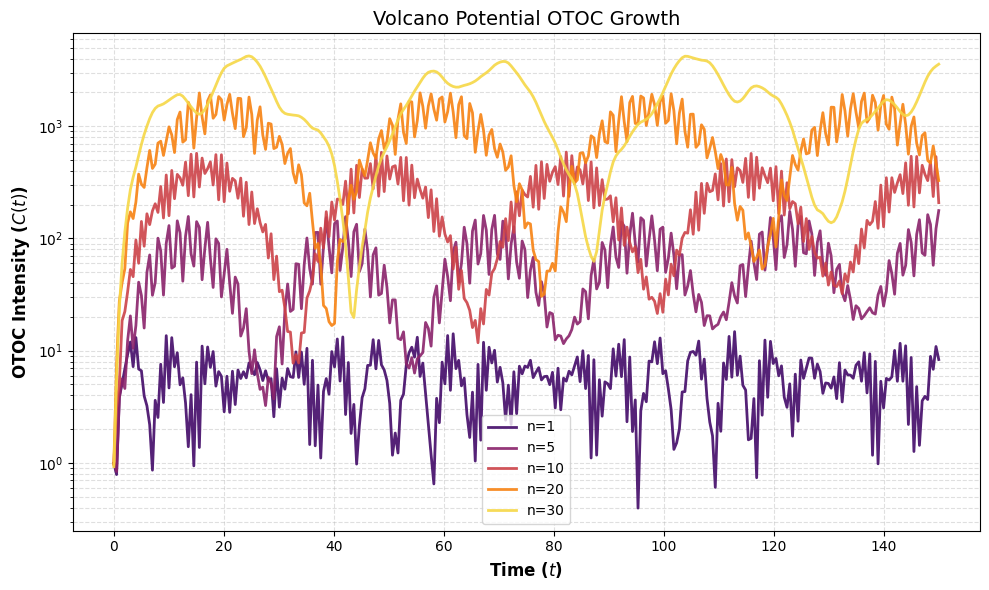

In [10]:
# Plot raw OTOC growth for selected states
plt.figure(figsize=(10, 6), dpi=100)
select_n = [1, 5, 10, 20, 30] # Select a few states to visualize
colors = cm.inferno(np.linspace(0.2, 0.9, len(select_n)))

for i, n in enumerate(select_n):
    if n < len(OTOC_list):
        plt.plot(t_range, OTOC_list[n], label=f'n={n}', color=colors[i], linewidth=2, alpha=0.9)

plt.grid(True, which="both", ls="--", alpha=0.4)  
plt.yscale('log')
plt.xlabel('Time ($t$)', fontsize=12, fontweight='bold')
plt.ylabel('OTOC Intensity ($C(t)$)', fontsize=12, fontweight='bold')
plt.title(f'Volcano Potential OTOC Growth', fontsize=14)
plt.legend(fontsize=10)
plt.tight_layout() 
plt.show()

Plot 2: Quantum-Classical Correspondence

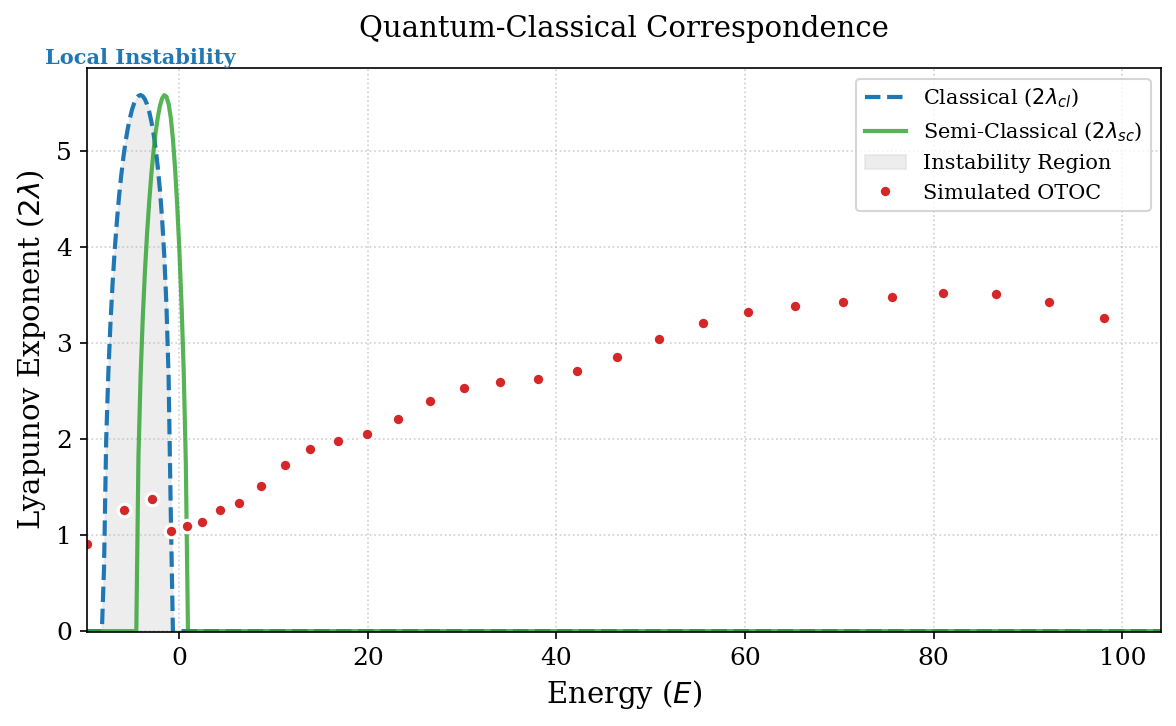

In [12]:
# --- Generate "Figure 4" Style Plot ---

# 1. Calculate Smooth Theoretical Curves
E_min = np.min(energies)
E_max = energies[min(limit_n_plot, len(energies)-1)]
E_smooth = np.linspace(E_min, E_max, 500)

lambda_smooth_c, lambda_smooth_sc = calculate_continuous_sensitivity(E_smooth, x_grid, V_grid, a1, a2, nu, mass)

# 2. Filter Simulation Data
sim_energies = []
sim_rates = []

for n in range(len(otoc_slopes)):
    if n < limit_n_plot and n < len(energies):
        sim_energies.append(energies[n])
        sim_rates.append(otoc_slopes[n])

# 3. Plotting
plt.figure(figsize=(8, 5), dpi=150)
plt.rcParams.update({'font.family': 'serif', 'font.size': 12})

# Theory
plt.plot(E_smooth, 2 * lambda_smooth_c, color='#1f77b4', linewidth=2, linestyle='--', label=r'Classical ($2\lambda_{cl}$)')
plt.plot(E_smooth, 2 * lambda_smooth_sc, color='#2ca02c', linewidth=2, linestyle='-', alpha=0.8, label=r'Semi-Classical ($2\lambda_{sc}$)')
plt.fill_between(E_smooth, 0, 2 * lambda_smooth_c, color='gainsboro', alpha=0.5, label='Instability Region')

# Simulation
plt.plot(sim_energies, sim_rates, 'o', color='#d62728', markersize=6, markeredgecolor='white', markeredgewidth=1.5, label=r'Simulated OTOC')

# Annotations
plt.xlabel(r'Energy ($E$)', fontsize=14)
plt.ylabel(r'Lyapunov Exponent ($2\lambda$)', fontsize=14)
plt.title(r'Quantum-Classical Correspondence', fontsize=14, pad=15)
plt.xlim(E_min, E_max)
plt.ylim(bottom=-0.01)

peak_idx = np.argmax(lambda_smooth_c)
plt.text(E_smooth[peak_idx], 2 * lambda_smooth_c[peak_idx] * 1.05, 'Local Instability', 
         ha='center', va='bottom', fontsize=10, color='#1f77b4', fontweight='bold')

plt.legend(frameon=True, fancybox=True, loc='upper right', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()